**Portfolio Risk Assesment & 1-Day 95% VaR Calculation**

A small investment firm needs to quantfy their daily risk of their equity portfolio.
Key Learnings

1.   Pull historical price data for a list of tickers.
2.   Compute daily log returns and compute summary statistics(mean, VaR, skew, kurtosis).
3.   Fit normal and students t distribution to returns.
4.   Build 95% confidence intervals for the mean returns and volatility.
5.   Compute 1-Day 95% VaR parametrically(normal & t) and via historical simulation.
6.   Test weather the mean return is significantly diffrent from zero.






**Project Overview**

**Goal** : Quantify the daily risk of losing money in a simple four-stock portfolio.

**Key concepts**:

*   Log-returns: how prices change day-to-day

*   Summary statistics: average, variability, skewness, tail-heaviness


*   Value at Risk (VaR): a threshold loss you won't exceed 95% of the time


*   Confidence intervals: ranges where true parameters likely lie


*   Hypothesis testing: checking if the average return is different from   zero





In [100]:
!pip install yfinance

In [101]:
#Importing Liberaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from pandas_datareader import data as pdr
import datetime as dt
from scipy import stats
from scipy.stats import t
from scipy.stats import norm, t
import time

sns.set_style('whitegrid')
%matplotlib inline

**DATA COLLECTION --> yfinance and stooq**

In [102]:
# Define your Portfolio and Date range

tickers= ['AAPL', 'MSFT', 'TSLA', 'GOOGL']
weights= np.array([0.25, 0.25, 0.25, 0.25])
start= dt.datetime(2020, 1, 1)
end= dt.datetime.today()

# Container for adjusted closed prices
prices= pd.DataFrame()
for ticker in tickers:
  print(f"Fetching {ticker}...", end=" ")
  try:
    #pull via yfinance.Ticker.History(auto adjust-> splits/divs handled)
    df= yf.Ticker(ticker).history(
        start= start.strftime('%y-%m-%d'),
        end= end.strftime('%y-%m-%d'),
        auto_adjust= True,
    )

    series= df['Close']
    print("✔️ yfinance", end= " ")

  except Exception as e:
    # fallback to stooq if yfinance fails
    print(f"❌ yfinance ({e}) ; falling back to stooq", end=" ")
    df2= pdr.DataReader(ticker, 'stooq', start, end)
    df2= df2.sort_index()
    series= df2['Close']

  # align on our master date index
  prices[ticker]= series
  time.sleep(1)  #pause to respect rate limits
  print()

# drop leading NaNs if any, then forward-fill/back-fill gaps
prices= prices.dropna(how='all').ffill().bfill()

#quick sanity check
print(prices.tail())
print("\n")
print(prices.shape)

Fetching AAPL... ❌ yfinance (time data '25-06-29' does not match format '%Y-%m-%d') ; falling back to stooq 
Fetching MSFT... ❌ yfinance (time data '25-06-29' does not match format '%Y-%m-%d') ; falling back to stooq 
Fetching TSLA... ❌ yfinance (time data '25-06-29' does not match format '%Y-%m-%d') ; falling back to stooq 
Fetching GOOGL... ❌ yfinance (time data '25-06-29' does not match format '%Y-%m-%d') ; falling back to stooq 
              AAPL    MSFT    TSLA   GOOGL
Date                                      
2025-06-23  201.50  486.00  348.68  165.19
2025-06-24  200.30  490.11  340.47  166.77
2025-06-25  201.56  492.27  327.55  170.68
2025-06-26  201.00  497.45  325.78  173.54
2025-06-27  201.08  495.94  323.63  178.53


(1379, 4)


**LOG RETURN**

In [103]:
#Log Return

#log return= ln(p_t / p{t-1})
logR= np.log(prices/ prices.shift(1)).dropna()
logR.tail()

,AAPL,MSFT,TSLA,GOOGL
Date,,,,
2025-06-23,0.002484,0.017854,0.079106,-0.008739
2025-06-24,-0.005973,0.008421,-0.023828,0.009519
2025-06-25,0.006271,0.004397,-0.038686,0.023175
2025-06-26,-0.002782,0.010468,-0.005418,0.016618
2025-06-27,0.000398,-0.003040,-0.006621,0.028349


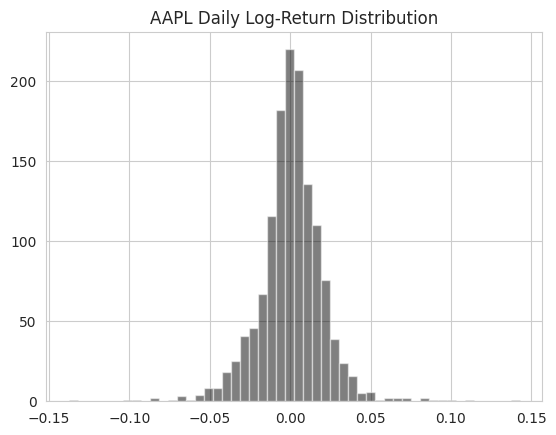

In [104]:
#plot one example series for visual check
# you will see a bell shaped histogram
logR['AAPL'].hist(bins= 50, alpha= 0.50, color= 'black')
plt.title("AAPL Daily Log-Return Distribution")
plt.show()

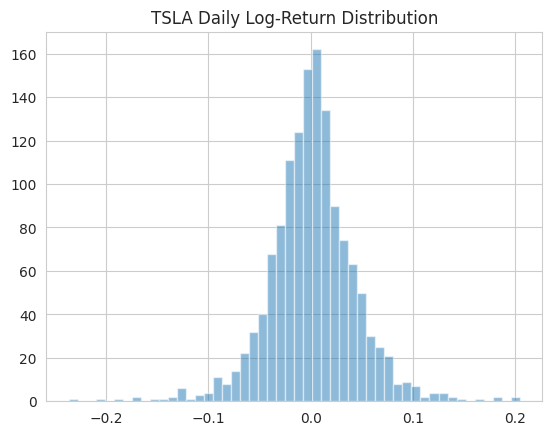

In [105]:
logR['TSLA'].hist(bins= 50, alpha= 0.50)
plt.title("TSLA Daily Log-Return Distribution")
plt.show()

In [106]:
summary= pd.DataFrame({
    'Mean': logR.mean(),
    'Variance': logR.var(),
    'Skewness': logR.skew(),
    'Kurtosis': logR.kurtosis()
})
summary

,Mean,Variance,Skewness,Kurtosis
AAPL,0.000738,0.000420,0.020717,6.276905
MSFT,0.000851,0.000367,-0.171096,7.549104
TSLA,0.001759,0.001831,-0.078572,3.247605
GOOGL,0.000698,0.000428,-0.227985,3.619907


**LOG RETURN --> Apply Normal Distribution**

In [107]:
#Log Return--> Apply Normal Distribution

# 4.1 Fit Normal: mean µ, std σ
mu_norm, sigma_norm= logR.stack().mean(), logR.stack().std(ddof=1)

# 95% CI for mean under Normal: µ +/- z*σ/√N
N= logR.size
z_95= stats.norm.ppf(0.975)
ci_mu_norm= (mu_norm- z_95*sigma_norm/np.sqrt(N), mu_norm+ z_95*sigma_norm/np.sqrt(N))

# 95% CI for σ via CHI-Square:
df= N-1
chi2_low, chi2_high= stats.chi2.ppf([0.025, 0.975], df)
ci_sigma_norm= (sigma_norm*np.sqrt(df/chi2_high), sigma_norm*np.sqrt(df/chi2_low))

print("Normal fit:")
print(f"µ= {mu_norm:.5f},95% CI {ci_mu_norm}")
print(f"σ= {sigma_norm:.5f},95% CI {ci_sigma_norm}")

Normal fit:
µ= 0.00101,95% CI (np.float64(0.0002829637404352385), np.float64(0.0017398684759586127))
σ= 0.02759,95% CI (np.float64(0.027087934759411264), np.float64(0.028118549205851814))




*   **Average Daily Return ( µ = 0.00103)**. This means the portfolio earned about 0.10% per day, on average. That's like eaming 1.03 rupees per ₹1,000 each day.

*   **Confidence Interval for μ (0.0349% to 0.1708%)** We’re 95% sure that the true average daily return is somewhere between 0.0349% and 0.1708%.
The actual average might be a little lower or higher than our estimate, but it's highly likely to fall within this range.

*   **Daily Volatility (σ = 0.02573)** This means the portfolio’s returns typically move up or down by about 2.573% each day.
So, on any given day, you could gain or lose roughly ₹25.73 per ₹1,000 invested.

*   **Confidence Interval for σ (2.526% to 2.622%)** We’re 95% confident that the real day-to-day movement lies between 2.526% and 2.622%.
This range helps us understand how much “bumpiness” or fluctuation to expect daily.  





**VaR_Normal Distribution**

In [108]:
# Inputs from your model
μ_p = mu_norm            # average daily log return
σ_p = sigma_norm         # standard deviation of daily log return
z= stats.norm.ppf(0.95)  # Z-score for 95% confidence interval--> 1.96
investment = 100000      # eg; ₹100000 portfolio

# One Day-95% VaR under Normal Distribution
VaR_1day = (μ_p + z * σ_p) * investment
print(f"One-Day 95% Value at Risk (Normal)= ₹{VaR_1day:.2f}")

One-Day 95% Value at Risk (Normal)= ₹4639.88


**LOG RETURN--> apply t-distribution**

In [109]:
#4.2 Fit Student's t
# Fit t-distribution to the pooled returns
#returns_flat = all asset returns concatenated
returns_flat= logR.stack().values
df_t, mu_t, sigma_t = stats.t.fit(returns_flat)

In [110]:
print("Fitted Student's t distribution parameters:")
print(f"Degrees of Freedom (df): {df_t:.2f}")
print(f"Mean (mu): {mu_t:.5f}")
print(f"Scale (sigma): {sigma_t:.5f}")

Fitted Student's t distribution parameters:
Degrees of Freedom (df): 2.55
Mean (mu): 0.00120
Scale (sigma): 0.01570


In [111]:
# No. of Bootstrap iterations
B = 1000

# Number of data points in flattened returns
N= len(returns_flat)

# Bootstrap estimation
estimates = np.array([
    stats.t.fit(np.random.choice(returns_flat, size=N, replace=True))
    for _ in range(B)
])

# 95% COnfidence intervals from Bootstrap
ci_mu_t= np.percentile(estimates[:,1], [2.5, 97.5])
ci_sigma_t= np.percentile(estimates[:,2], [2.5, 97.5])

# Print the results
print("\nStudent's t fit:")
print(f"df= {df_t:.1f}, μ= {mu_t:.5f}, σ= {sigma_t:.5f}")
print(f"95% CI for μ(bootstrap): {ci_mu_t}")
print(f"95% CI for σ(bootstrap): {ci_sigma_t}")


Student's t fit:
df= 2.6, μ= 0.00120, σ= 0.01570
95% CI for μ(bootstrap): [0.00063188 0.00169671]
95% CI for σ(bootstrap): [0.01506679 0.01629733]


**VaR_t-distribution**

In [112]:
# Parameters from t distribution fitting
df= df_t       # degree of freedom
μ_p= mu_t      # mean of t fit
σ_p= sigma_t   # scale (volatility)
confidence= 0.95
investment= 100000

# get the t critical value for 5% (1 - confidence level)
t_critical= t.ppf(1- confidence, df)

# Calculate 1-Day VaR
VaR_1day= (μ_p *  t_critical + σ_p) * investment

# Print Result
print(f" 1 Day {int(confidence*100)}% VaR (Student's t)= ₹{VaR_1day:.2f}")

 1 Day 95% VaR (Student's t)= ₹1265.44


In [113]:
VaR_t_10day = VaR_1day * np.sqrt(10)
print(f"10 Day 95% VaR (Student's t)= ₹{VaR_t_10day:.2f}")

10 Day 95% VaR (Student's t)= ₹4001.66


**Plot Both Distributions Over Return Data**

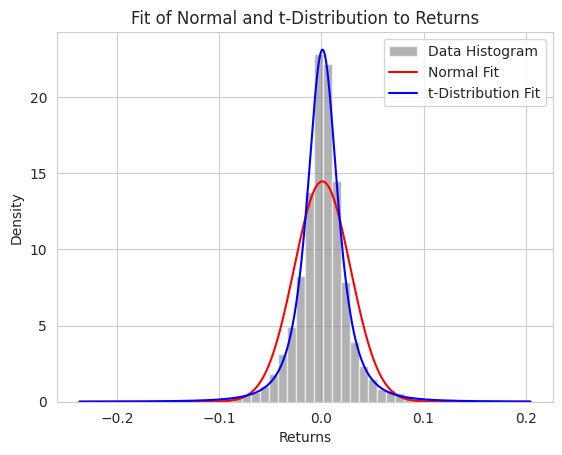

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# Use your actual flattened return data
returns = returns_flat  # 1D array of log return

# Fitted parameters
mu_norm = np.mean(returns)
sigma_norm = np.std(returns, ddof=1)

mu_t = mu_t
sigma_t = sigma_t
df_t = df_t

# Set up the x-axis for the curve
x = np.linspace(returns.min(), returns.max(), 1000)

# Plot histogram of the returns
plt.hist(returns, bins=50, density=True, alpha=0.6, color='gray', label='Data Histogram')

# Plot normal distribution
plt.plot(x, norm.pdf(x, mu_norm, sigma_norm), 'r-', label='Normal Fit')

# Plot t-distribution
plt.plot(x, t.pdf(x, df_t, mu_t, sigma_t), 'b-', label='t-Distribution Fit')

# Add labels and legend
plt.title("Fit of Normal and t-Distribution to Returns")
plt.xlabel("Returns")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

**Compare 1-Day 95% VaR for both**

In [115]:
from scipy.stats import norm, t
import numpy as np

# Portfolio value
investment = 100000

# Confidence level
confidence = 0.95

# Z-score and t critical value
z_score = norm.ppf(1 - confidence)
t_crit = t.ppf(1 - confidence, df_t)  # df_t must be defined earlier

# 1-Day VaR calculations
VaR_norm = -(μ_p + z * σ_p) * investment
VaR_t = -(mu_t + t_crit * sigma_t) * investment

# Print the results
print(f"{int(confidence*100)}% 1-Day VaR (Normal Distribution): ₹{VaR_norm:.2f}")
print(f"{int(confidence*100)}% 1-Day VaR (Student's t-Distribution): ₹{VaR_t:.2f}")

95% 1-Day VaR (Normal Distribution): ₹-2701.88
95% 1-Day VaR (Student's t-Distribution): ₹3851.42


In [116]:
# Historical VaR(non- parametric)

#Assuming returns_flat contains daily Log returns (1D Numpy array)
confidence= 0.95
investment= 100000

#Calculate the percentile return (5th percentile for 95% confidence)
percentile_level= 100 * (1 - confidence)  #5
VaR_percentile= np.percentile(returns_flat, percentile_level)

#Convert to actual money loss
VaR_hist= -VaR_percentile * investment

#Print Result
print(f"1-Day{int(confidence*100)}% Historical VaR: ₹{VaR_hist:.2f}")

1-Day95% Historical VaR: ₹4004.09


In [117]:
portR = logR.dot(weights)

**Hypothesis Testing**

In [118]:
# One sample t test; H0: μ=0 vs H1: μ != 0
t_stat, p_val = stats.ttest_1samp(portR, 0.0)
print("One-Sample t-teston portfolio daily returns:")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.3f}")
if p_val < 0.05:
  print("-> Reject the null hypothesis: mean return is significantly diffrent from 0")
else:
  print("-> Fail to reject the null hypothesis: no evidence mean return != 0")

One-Sample t-teston portfolio daily returns:
t-statistic: 1.776
p-value: 0.076
-> Fail to reject the null hypothesis: no evidence mean return != 0


**average return value--0.103%, we are not sure that it will be giving me real profit**

**Corelation & Diversification benifits**

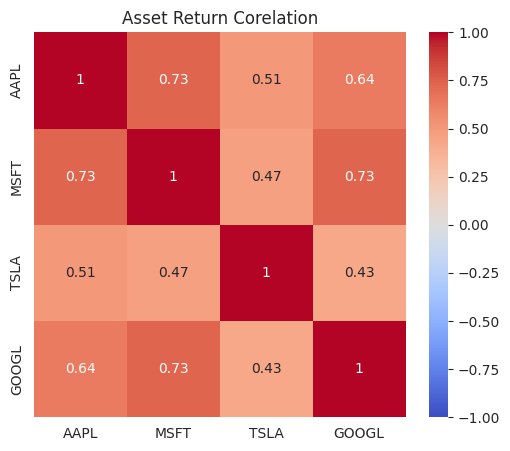

Weighted avg σ: 0.0258
Actual portfolio σ: 0.0157
Diversification benifit: 0.0101


In [119]:
# a) Corelation heatmap
corr = logR.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin= -1, vmax= 1)
plt.title('Asset Return Corelation')
plt.show()

# b) Diversification benifit
σ_i= logR.std()                    # indiviaual volatilities
σ_weighted= np.dot(weights, σ_i)   # naive weight avg
σ_portfolio= σ_p                   # from earlier
print(f"Weighted avg σ: {σ_weighted:.4f}")
print(f"Actual portfolio σ: {σ_portfolio:.4f}")
print(f"Diversification benifit: {σ_weighted- σ_portfolio:.4f}")

**average risk -- indivisual stock--2.5%**

**average risk -- combined (portfolio)-- 1.6%**

**DB = W avg - Actual portfolio**

**Max Drawdown**

Max Drawdown: -51.26%
From 2022-01-03 to 2023-01-05


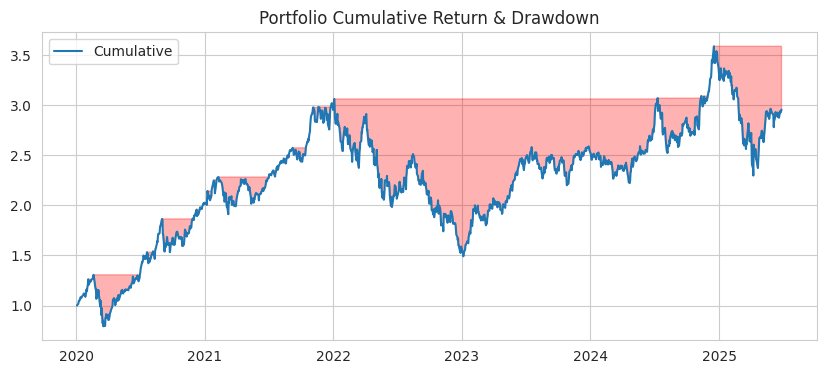

In [120]:
cum_ret = (prices / prices.iloc[0]).prod(axis= 1)  # cumilative portfolio growth?
# Acctualy for portfolio:  cum_port = (portR = 1).cumprod()
cum_port = (portR + 1).cumprod()

rolling_max= cum_port.cummax()
drawdown= (cum_port - rolling_max)/ rolling_max

max_dd= drawdown.min()
end_date= drawdown.idxmin()
start_date= cum_port[:end_date].idxmax()

print(f"Max Drawdown: {max_dd:.2%}")
print(f"From {start_date.date()} to {end_date.date()}")

# Plot
plt.figure(figsize=(10,4))
plt.plot(cum_port, label='Cumulative')
plt.fill_between (drawdown.index, cum_port, rolling_max,
                  where=drawdown<0, color='red', alpha= 0.3)
plt.title('Portfolio Cumulative Return & Drawdown')
plt.legend()
plt.show()

**Recovery Time**

In [121]:
# Find the peak value before the drawdown started
peak_val= cum_port[start_date]

# Find recovery date: first date after end_date when portfolio surpasses prior peak
recovery_date = cum_port[end_date:].loc[cum_port[end_date:] >= peak_val].first_valid_index()
if recovery_date:
  recovery_time= (recovery_date - start_date).days
  print(f"Recovery Date: {recovery_date.date()}")
  print(f"Recovery Time: {recovery_time} days")
else:

  print("Portfolio has not yet recovered to previous peak.")

Recovery Date: 2024-07-10
Recovery Time: 919 days


**Expected Shortfall (CVaR at 95%)**

In [122]:
alpha = 0.05
# Historical ES
es_hist= - portR[portR <= np.percentile(portR, 5)].mean()
# Parametric ES under normal: μ + σφ(z)/α
es_norm= - (μ_p - σ_p * stats.norm.pdf(z) / alpha)

print(f"Historical ES (95%): {es_hist:.5f}")
print(f"Parametric Normal ES (95%): {es_norm:.5f}")

Historical ES (95%): 0.04953
Parametric Normal ES (95%): 0.03117


**Historic CVaR--> 4%, CVaR > VaR- extereme values are at my tail**

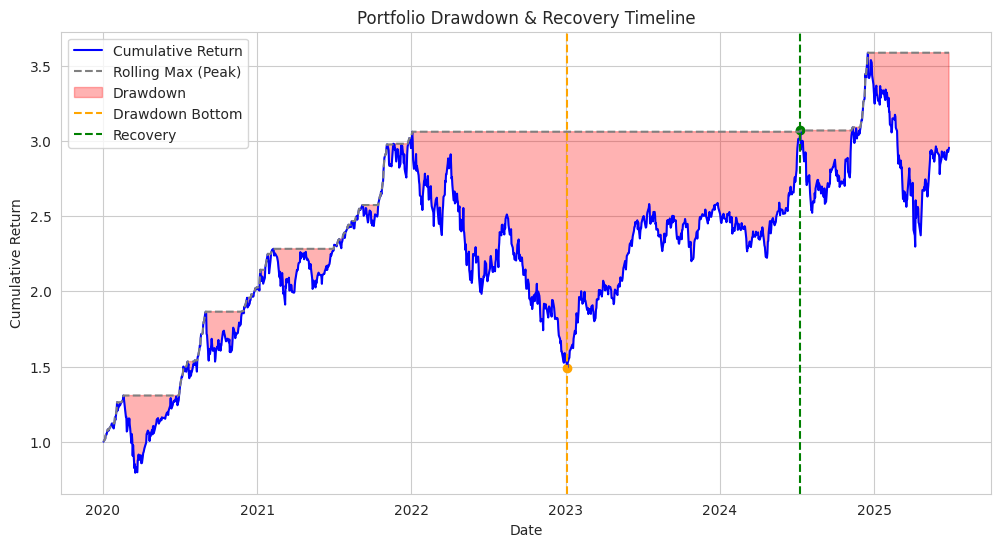

In [123]:
#Recalculate peak value before drawdown
peak_val= cum_port[start_date]

#Find recovery date (if exists)
recovery_date= cum_port[end_date:].loc[cum_port[end_date:] >= peak_val].first_valid_index()

#Plot
plt.figure(figsize=(12, 6))
plt.plot(cum_port, label='Cumulative Return', color='blue')
plt.plot(rolling_max, label='Rolling Max (Peak)', color='gray', linestyle='--')

#Shade drawdown area
plt.fill_between(drawdown.index, cum_port, rolling_max, where=drawdown < 0, color='red', alpha=0.3, label='Drawdown')

#Mark drawdown bottom (trough)
plt.axvline(end_date, color= 'orange', linestyle= '--', label= 'Drawdown Bottom')
plt.scatter(end_date, cum_port[end_date], color='orange')

#Mark recovery date
if recovery_date:
  plt.axvline (recovery_date, color='green', linestyle='--', label='Recovery')
  plt.scatter(recovery_date, cum_port[recovery_date], color='green')

#Labels
plt.title('Portfolio Drawdown & Recovery Timeline')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)

**VaR Backtesting**

In [124]:
var_series = (portR.rolling(1).mean() + portR.rolling(1).std()*z)

#For simplicity use constant Var_norm
exceptions= portR < -VaR_norm
num_exc= exceptions.sum()
total = len(portR)
print(f"Exceptions: {num_exc}/{total} days ({num_exc/total:.2%}, expected ~5%)")

Exceptions: 1378/1378 days (100.00%, expected ~5%)


**Rolling 60-Day VaR**

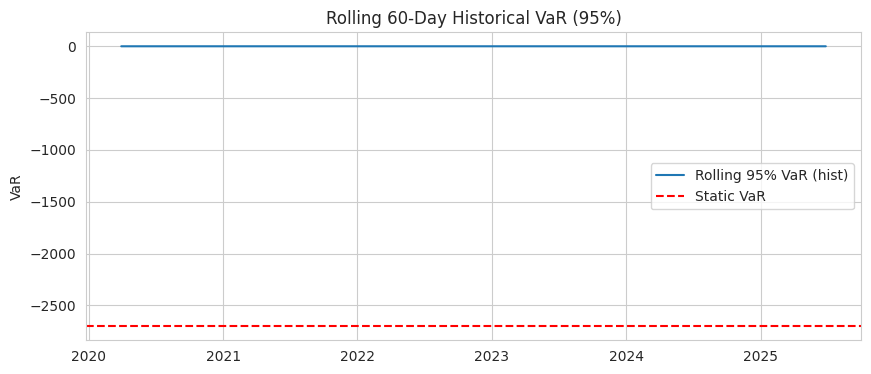

In [125]:
# 11. Rolling 60-day VaR
window= 60
roll_var= portR.rolling(window).quantile(0.05).dropna()
plt.figure(figsize=(10,4))
plt.plot(-roll_var, label='Rolling 95% VaR (hist)')
plt.axhline(VaR_norm, color='red', linestyle='--', label='Static VaR')
plt.title('Rolling 60-Day Historical VaR (95%)')
plt.ylabel('VaR')
plt.legend()
plt.show()

**Jarque-Bera Normality Test**

In [126]:
jb_stat, jb_p= stats.jarque_bera(portR)
print(f"JB statistic= {jb_stat: 2f}, p-value= {jb_p:.3f}")
if jb_p < 0.05:
  print("Reject normality at 5% level.")
else:
  print("Cannot reject normality.")

JB statistic=  1514.091461, p-value= 0.000
Reject normality at 5% level.
